### Table structure

![Screenshot 2026-05-19 115945.png](<attachment:Screenshot 2026-05-19 115945.png>)
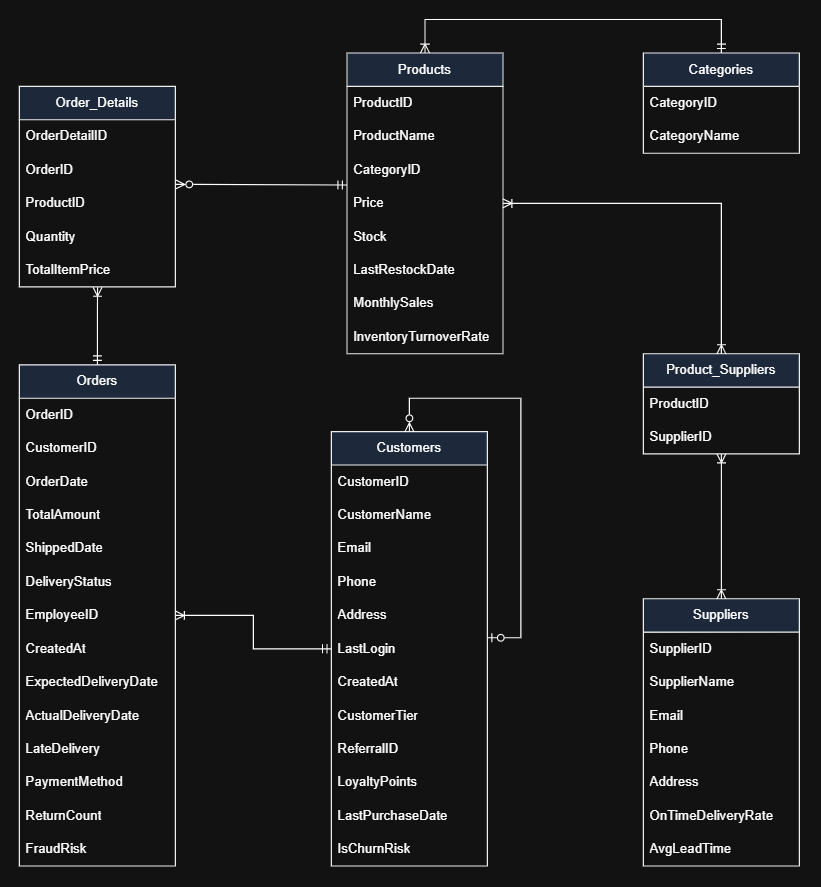

In [2]:
pip install mysql

   ---------------------------------------- 0.0/206.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/206.9 kB ? eta -:--:--
   ----------- --------------------------- 61.4/206.9 kB 825.8 kB/s eta 0:00:01
   ---------------------------------------- 206.9/206.9 kB 1.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
%pip install mysql-connector-python

   ---------------------------------------- 0.0/17.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/17.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/17.7 MB 640.0 kB/s eta 0:00:28
   ---------------------------------------- 0.1/17.7 MB 1.2 MB/s eta 0:00:15
   -- ------------------------------------- 1.1/17.7 MB 8.6 MB/s eta 0:00:02
   ---- ----------------------------------- 2.1/17.7 MB 13.5 MB/s eta 0:00:02
   -------- ------------------------------- 3.8/17.7 MB 18.8 MB/s eta 0:00:01
   ----------- ---------------------------- 5.2/17.7 MB 20.8 MB/s eta 0:00:01
   ---------------- ----------------------- 7.1/17.7 MB 24.0 MB/s eta 0:00:01
   --------------------- ------------------ 9.5/17.7 MB 27.5 MB/s eta 0:00:01
   ------------------------ --------------- 10.9/17.7 MB 38.6 MB/s eta 0:00:01
   ----------------------------- ---------- 13.0/17.7 MB 43.7 MB/s eta 0:00:01
   ---------------------------------- ----- 15.1/17.7 MB 46.9 MB/s eta 0:00:01



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import mysql.connector
from mysql.connector import Error

# Easy Level SQL Queries

## 1. Count the number of customers per tier
**Problem:** Count how many customers belong to each tier ('New', 'Regular', 'VIP').

**Solution:**
```sql
SELECT   CustomerTier, 
         COUNT(*) AS Total
FROM     Customers
GROUP BY CustomerTier;
```

---

## 2. Count how many orders exist per delivery status
**Problem:** Find out how many orders fall under each delivery status.

**Solution:**
```sql
SELECT   DeliveryStatus, 
         COUNT(*) AS OrderCount
FROM     Orders
GROUP BY DeliveryStatus;
```

---

## 3. Count the number of products for each category
**Problem:** Return the number of products in each category.

**Solution:**
```sql
SELECT   CategoryID, 
         COUNT(*) AS ProductCount
FROM     Products
GROUP BY CategoryID;
```

---

## 4. Count the number of suppliers per product
**Problem:** Find out how many suppliers are associated with each product.

**Solution:**
```sql
SELECT   ProductID, 
         COUNT(*) AS SupplierCount
FROM     Product_Suppliers
GROUP BY ProductID;
```

---

## 5. Count how many customers were referred by each existing customer
**Problem:** Find out how many referrals each customer has made (exclude NULL ReferralID).

**Solution:**
```sql
SELECT   ReferralID, 
         COUNT(*) AS Referrals
FROM     Customers
WHERE    ReferralID IS NOT NULL
GROUP BY ReferralID;
```

# Medium Level SQL Queries

## 1. Count how many VIP customers placed at least one order
**Problem:** Find the number of orders each VIP customer has placed.

**Solution:**
```sql
SELECT   c.CustomerID, 
         COUNT(o.OrderID) AS NumOrders
FROM     Customers c
LEFT JOIN Orders o ON c.CustomerID = o.CustomerID
WHERE    c.CustomerTier = 'VIP'
GROUP BY c.CustomerID;
```

---

## 2. Count how many products have more than 10 monthly sales
**Problem:** Count how many products have more than 10 units sold per month.

**Solution:**
```sql
SELECT   COUNT(*) AS HighSalesProducts
FROM     Products
WHERE    MonthlySales > 10;
```

---

## 3. Count orders placed using each payment method
**Problem:** Count how many orders were placed using each payment method.

**Solution:**
```sql
SELECT   PaymentMethod, 
         COUNT(*) AS NumOrders
FROM     Orders
GROUP BY PaymentMethod;
```

---

## 4. Count how many products were ordered more than once
**Problem:** Find all products that have been ordered more than once.

**Solution:**
```sql
SELECT   ProductID, 
         COUNT(*) AS TimesOrdered
FROM     Order_Details
GROUP BY ProductID
HAVING   COUNT(*) > 1;
```

---

## 5. Count the number of orders that were returned
**Problem:** Count the number of orders that have at least one return (ReturnCount > 0).

**Solution:**
```sql
SELECT   COUNT(*) AS ReturnedOrders
FROM     Orders
WHERE    ReturnCount > 0;
```

# Hard Level SQL Queries

## 1. Top 5 most ordered products by total quantity
**Problem:** Find the top 5 best-selling products based on the total quantity ordered across all orders.

**Solution:**
```sql
SELECT   p.ProductName,
         SUM(od.Quantity) AS TotalQuantity
FROM     Order_Details od
JOIN     Products p ON od.ProductID = p.ProductID
GROUP BY p.ProductName
ORDER BY TotalQuantity DESC
LIMIT    5;
```

---

## 2. Count of distinct products purchased by each customer
**Problem:** Find out how many unique products each customer has ordered across all their orders.

**Solution:**
```sql
SELECT   o.CustomerID, 
         COUNT(DISTINCT od.ProductID) AS UniqueProducts
FROM     Orders o
JOIN     Order_Details od ON o.OrderID = od.OrderID
GROUP BY o.CustomerID;
```

---

## 3. Count orders per customer for those with more than 2 orders
**Problem:** Find customers who have placed more than 2 orders.

**Solution:**
```sql
SELECT   CustomerID, 
         COUNT(*) AS TotalOrders
FROM     Orders
GROUP BY CustomerID
HAVING   COUNT(*) > 2;
```

---

## 4. Count how many late deliveries each employee is responsible for
**Problem:** Find out how many late deliveries are associated with each employee (where LateDelivery = TRUE and EmployeeID is not NULL).

**Solution:**
```sql
SELECT   EmployeeID, 
         COUNT(*) AS LateDeliveries
FROM     Orders
WHERE    LateDelivery = 1 
         AND EmployeeID IS NOT NULL
GROUP BY EmployeeID;
```

---

## 5. Count customers who haven't made any purchases
**Problem:** Count how many customers have never made a purchase (LastPurchaseDate is NULL).

**Solution:**
```sql
SELECT   COUNT(*) AS InactiveCustomers
FROM     Customers
WHERE    LastPurchaseDate IS NULL;
```